In [3]:
import numpy as np
import cv2
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 500)
import matplotlib.patches as patches
import math
from utils import *
from PIL import Image
import torch

In [4]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [5]:
class MPII_dataset(Dataset):
    
    def __init__(self, custom_transforms=None):
        dataset_path = os.path.join('data', 'mpii')
        annotations_path = os.path.join(dataset_path, 'annotations')
        self.images_path = os.path.join(dataset_path, 'images_cropped')
    
        self.custom_transforms = custom_transforms
        df_name = 'trainval_unique_cropped.csv'
        df_fullpath = os.path.join(annotations_path, df_name)
        self.df = pd.read_csv(df_fullpath)
        self.num_samples = len(self.df)
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, index):
        current_sample = self.df.iloc[index] # row of dataframe
        filename = current_sample[0] # name of the image file

        full_path_image = os.path.join(self.images_path, filename) # full path to image file
        image = Image.open(full_path_image)

        # height, width, num_chanels = get_image_shape(image)
        height = self.df.iloc[index]['height']
        width = self.df.iloc[index]['width']

        center = np.array(current_sample[1:3]).astype(np.float32) # center of human
        scale = np.array(current_sample[3]).astype(np.float32) # scale of human

        joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
        visibility_array = np.array(current_sample[36:36+16]).astype(np.int64) # which joints are visible
        
        if self.custom_transforms is None:
            self.custom_transforms = transforms.Compose([
                transforms.ToTensor()
            ])
        
        image = self.custom_transforms(image)
        
        
        return image, torch.tensor(joints_coordinates), torch.tensor(visibility_array), torch.tensor(height), torch.tensor(width), torch.tensor(center)

In [6]:
mpii_dataset = MPII_dataset()
dataloader = DataLoader(mpii_dataset, batch_size=1, shuffle=True)

In [15]:
image_batch, joint_coordinates_batch, visibility_array_batch, height_batch, width_batch, center_batch = next(iter(dataloader))

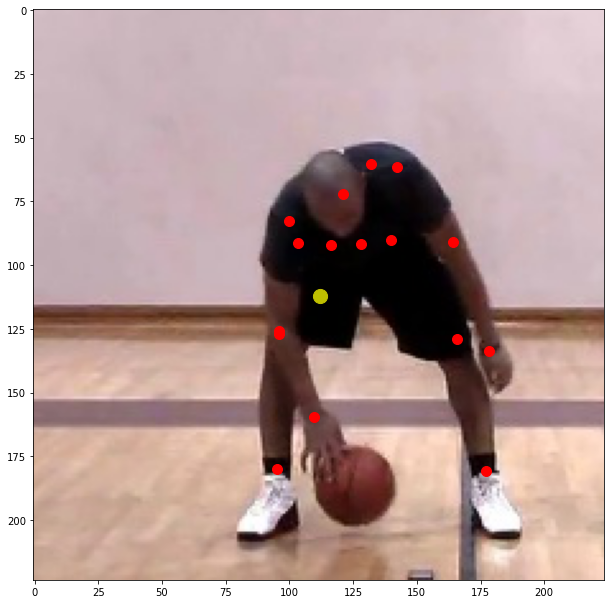

In [16]:
image_index = 0
image = image_batch[image_index].permute(1, 2, 0).detach().cpu().numpy()
joint_coordinates_combined = joint_coordinates_batch[image_index].detach().cpu().numpy()
joints_X = joint_coordinates_combined[::2]
joints_Y = joint_coordinates_combined[1::2]


visibility_array = visibility_array_batch[image_index].detach().cpu().numpy()
height = height_batch[image_index].detach().cpu().numpy()
width = width_batch[image_index].detach().cpu().numpy()
center = center_batch[image_index].detach().cpu().numpy()
display_overlaid_image(image, joints_X, joints_Y, center)

In [10]:
def display_overlaid_image(image, joints_X, joints_Y, center):
    fig, ax = plt.subplots(1)
    fig.set_size_inches(18.5, 10.5)

    joints_X = np.array(joints_X[joints_X>0])
    joints_Y = np.array(joints_Y[joints_Y>0])

    plt.imshow(image)
    plt.scatter(center[0]*224, center[1]*224, marker='o', color='y', s=200) # plot center of the human
    plt.scatter(joints_X*224, joints_Y*224, color='r', s=100) # plot the joints
    plt.show()